In [35]:

import seaborn as sns
from sklearn.datasets import load_iris
import pandas as pd 
import matplotlib.pyplot as plt
import os
os.environ["OMP_NUM_THREADS"] = "1"
from sklearn.cluster import KMeans

In [8]:
iris = load_iris()
X=iris.data
y=iris.target

In [9]:
X.shape

(150, 4)

<Axes: >

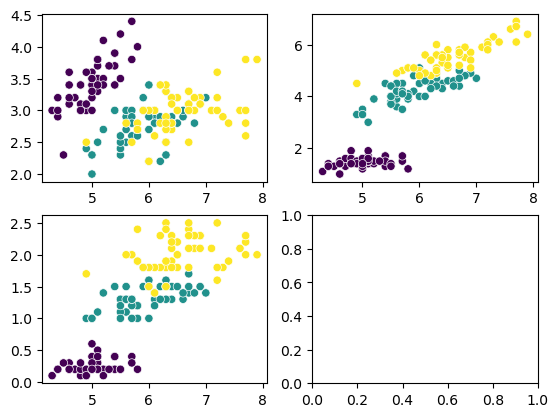

In [16]:
## Visualize the data
fig , ax = plt.subplots(2,2)
sns.scatterplot(ax=ax[0][0],x=X[:,0],y=X[:,1],c=y)
sns.scatterplot(ax=ax[0][1],x=X[:,0],y=X[:,2],c=y)
sns.scatterplot(ax=ax[1][0],x=X[:,0],y=X[:,3],c=y)
## two categories are overlaping with other 


In [18]:
## scaled our data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [39]:
## Elbow method
import warnings
warnings.filterwarnings("ignore")
wcss=[]
for k in range(2,21):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) 

In [40]:
wcss

[222.36170496502308,
 191.02473685317963,
 114.35407164049778,
 91.04766991109528,
 81.55075699571756,
 80.77773933734284,
 64.4267484948227,
 55.70690047933692,
 51.12109539650555,
 48.5923755215718,
 40.41066736393249,
 38.9316371999329,
 36.83696904794064,
 35.044380596624435,
 32.15603092396644,
 30.12572080300833,
 29.122039909056507,
 28.17442783661009,
 27.452326701356334]

<Axes: >

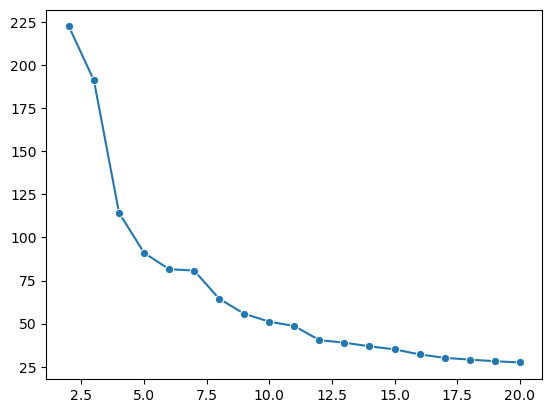

In [41]:
sns.lineplot(x=range(2,21),y=wcss,marker='o')

Text(0.5, 1.0, 'After training')

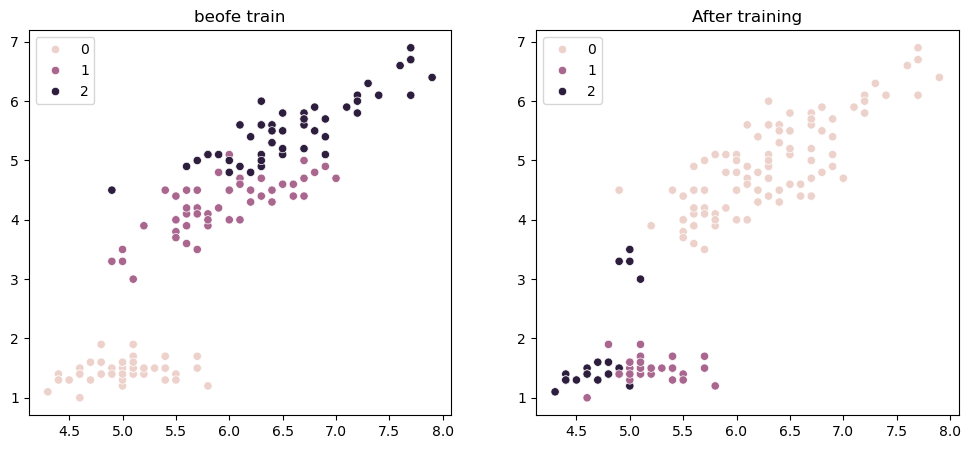

In [47]:
# Train final model 
kmeans=KMeans(
    n_clusters=3,
    random_state=42
)
labels = kmeans.fit_predict(X_scaled)
fig ,ax = plt.subplots(1,2,figsize=(12,5))
sns.scatterplot(ax=ax[0],x=X[:,0],y=X[:,2],hue=y)
ax[0].set_title('beofe train')
sns.scatterplot(ax=ax[1],x=X[:,0],y=X[:,2],hue=labels)
ax[1].set_title("After training")
